In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir("."))

Current directory: d:\DA projects\heart-disease-portfolio\notebooks

Files in current directory:
['01_data_understanding.ipynb']


In [5]:
import os

print("Current dir:", os.getcwd())
print("\n--- notebooks/ mein kya hai ---")
print(os.listdir("."))

print("\n--- Parent (heart-disease-portfolio/) mein kya hai ---")
print(os.listdir(".."))

# Check karo data/raw folder aur CSV
base = ".."
data_path = os.path.join(base, "data")
raw_path = os.path.join(data_path, "raw")
csv_path = os.path.join(raw_path, "Heart_disease_statlog.csv")

print("\n--- Checking paths ---")
print(f"data folder exists?  {os.path.exists(data_path)}")
print(f"raw folder exists?   {os.path.exists(raw_path)}")
print(f"CSV exists?          {os.path.exists(csv_path)}")

if os.path.exists(raw_path):
    print("\n--- data/raw/ mein kya files hain ---")
    print(os.listdir(raw_path))

Current dir: d:\DA projects\heart-disease-portfolio\notebooks

--- notebooks/ mein kya hai ---
['01_data_understanding.ipynb']

--- Parent (heart-disease-portfolio/) mein kya hai ---
['data', 'notebooks', 'reports', 'src']

--- Checking paths ---
data folder exists?  True
raw folder exists?   True
CSV exists?          True

--- data/raw/ mein kya files hain ---
['Heart_disease_statlog.csv']


In [6]:
df = pd.read_csv("../data/raw/Heart_disease_statlog.csv", encoding="utf-8-sig")
df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()

print("Shape:", df.shape)
df.head()

Shape: (270, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  270 non-null    int64  
 4   chol      270 non-null    int64  
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   270 non-null    int64  
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,270.0,54.433333,9.109067,29.0,48.0,55.0,61.0,77.0
sex,270.0,0.677778,0.468195,0.0,0.0,1.0,1.0,1.0
cp,270.0,2.174074,0.950090,0.0,2.0,2.0,3.0,3.0
trestbps,270.0,131.344444,17.861608,94.0,120.0,130.0,140.0,200.0
chol,270.0,249.659259,51.686237,126.0,213.0,245.0,280.0,564.0
fbs,270.0,0.148148,0.355906,0.0,0.0,0.0,0.0,1.0
restecg,270.0,1.022222,0.997891,0.0,0.0,2.0,2.0,2.0
thalach,270.0,149.677778,23.165717,71.0,133.0,153.5,166.0,202.0
exang,270.0,0.329630,0.470952,0.0,0.0,0.0,1.0,1.0
oldpeak,270.0,1.050000,1.145210,0.0,0.0,0.8,1.6,6.2


In [9]:
missing = df.isna().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing:", missing.sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


In [10]:
dups = df.duplicated().sum()
print("Duplicate rows:", dups)

Duplicate rows: 0


In [11]:
unique_counts = df.nunique().sort_values()
print(unique_counts)

sex           2
fbs           2
exang         2
target        2
restecg       3
slope         3
thal          3
cp            4
ca            4
oldpeak      39
age          41
trestbps     47
thalach      90
chol        144
dtype: int64


In [12]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index())


--- sex ---
sex
0     87
1    183
Name: count, dtype: int64

--- cp ---
cp
0     20
1     42
2     79
3    129
Name: count, dtype: int64

--- fbs ---
fbs
0    230
1     40
Name: count, dtype: int64

--- restecg ---
restecg
0    131
1      2
2    137
Name: count, dtype: int64

--- exang ---
exang
0    181
1     89
Name: count, dtype: int64

--- slope ---
slope
0    130
1    122
2     18
Name: count, dtype: int64

--- ca ---
ca
0    160
1     58
2     33
3     19
Name: count, dtype: int64

--- thal ---
thal
1    152
2     14
3    104
Name: count, dtype: int64

--- target ---
target
0    150
1    120
Name: count, dtype: int64


In [13]:
print("Target counts:")
print(df["target"].value_counts())

print("\nTarget percentage:")
print(df["target"].value_counts(normalize=True) * 100)

Target counts:
target
0    150
1    120
Name: count, dtype: int64

Target percentage:
target
0    55.555556
1    44.444444
Name: proportion, dtype: float64


C:\Users\NLP\AppData\Local\Temp\ipykernel_17616\1400371407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="target", palette=["#2ecc71", "#e74c3c"])
C:\Users\NLP\AppData\Local\Temp\ipykernel_17616\1400371407.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Disease (0)", "Disease (1)"])


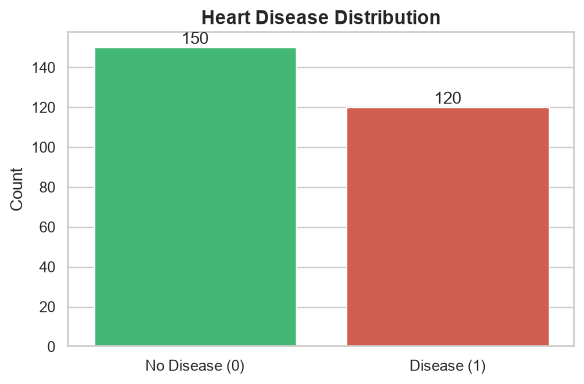

In [14]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="target", palette=["#2ecc71", "#e74c3c"])
ax.set_title("Heart Disease Distribution")
ax.set_xticklabels(["No Disease (0)", "Disease (1)"])
ax.set_xlabel("")
ax.set_ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig("../reports/figures/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

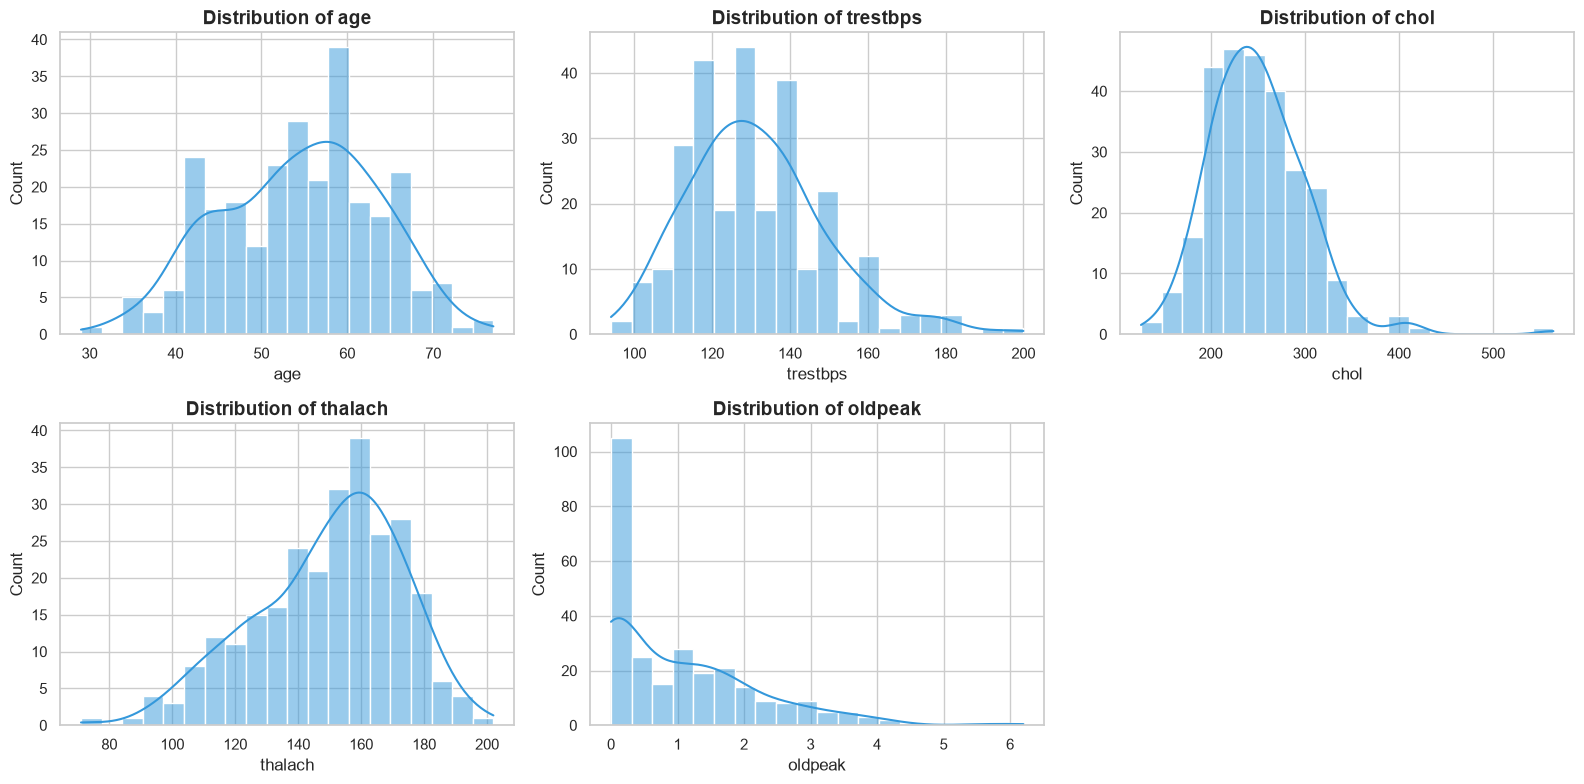

In [15]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i], color="#3498db")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig("../reports/figures/02_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

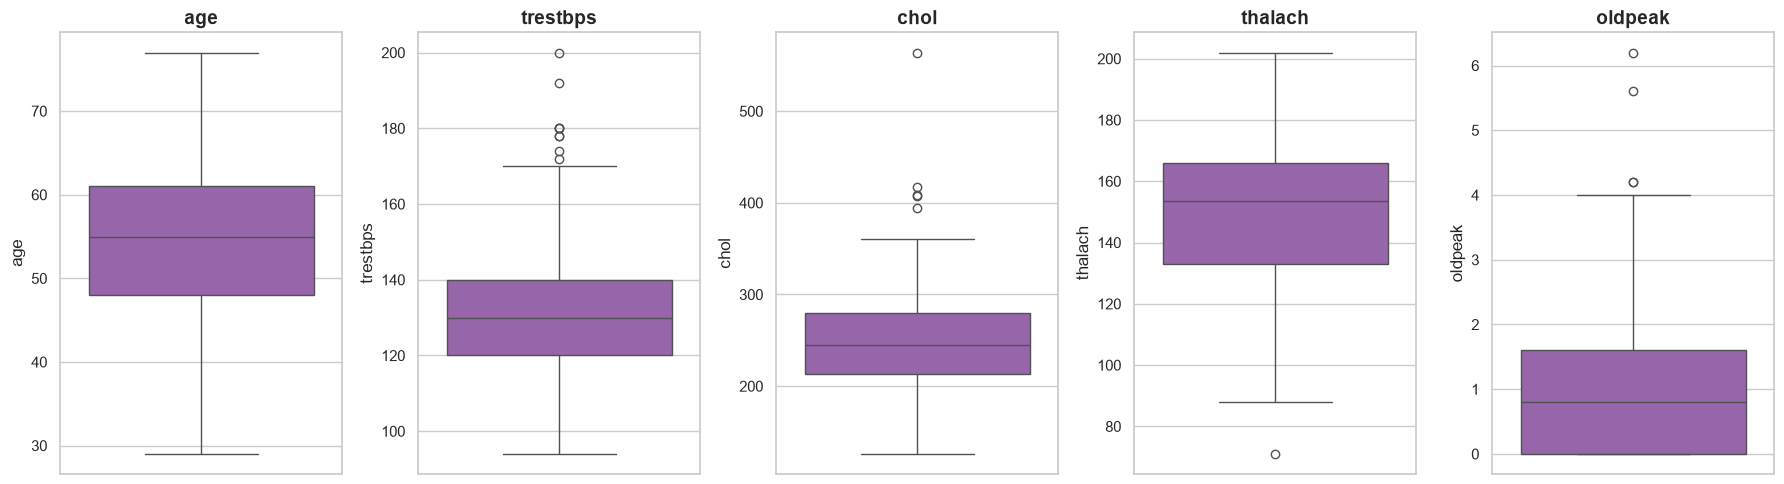

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#9b59b6")
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("../reports/figures/03_numeric_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

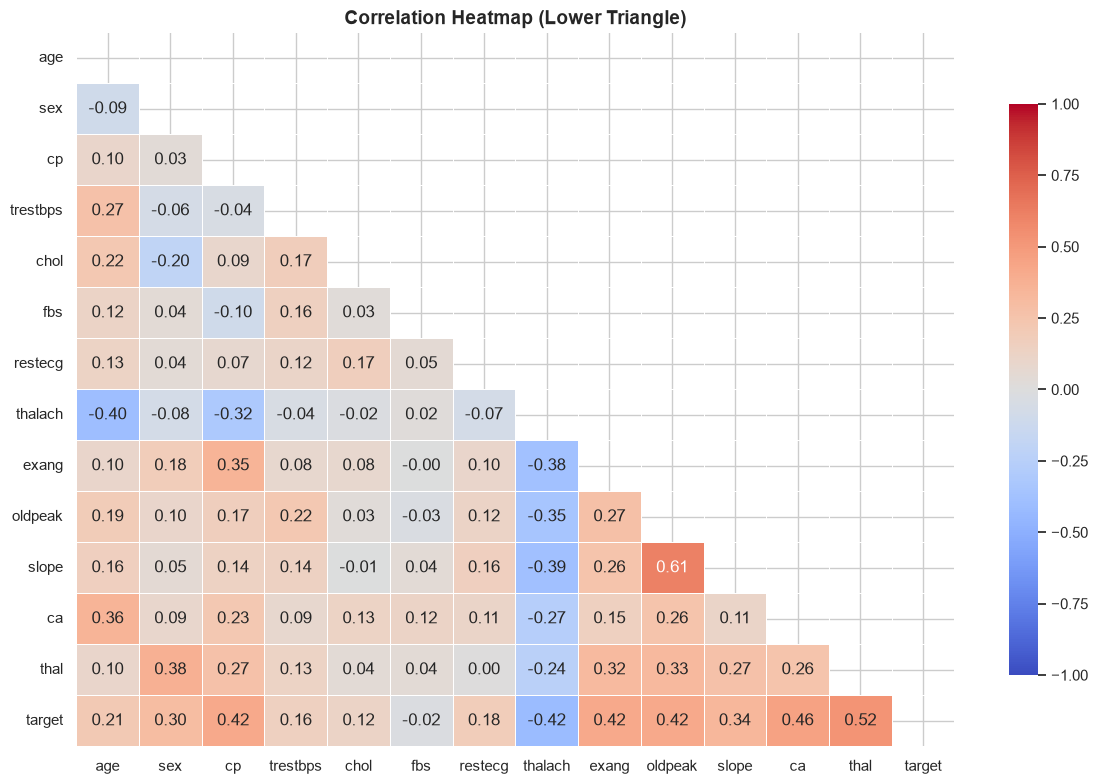

In [17]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm",
            fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.savefig("../reports/figures/04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
target_corr = df.corr(numeric_only=True)["target"].sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

Correlation with target:
target      1.000000
thal        0.524225
ca          0.455336
exang       0.419303
oldpeak     0.417967
cp          0.417436
slope       0.337616
sex         0.297721
age         0.212322
restecg     0.182091
trestbps    0.155383
chol        0.118021
fbs        -0.016319
thalach    -0.418514
Name: target, dtype: float64


In [19]:
df.to_csv("../data/processed/heart_clean.csv", index=False)
print("Cleaned data saved to data/processed/heart_clean.csv")
print("Final shape:", df.shape)

Cleaned data saved to data/processed/heart_clean.csv
Final shape: (270, 14)
